In [ ]:
# Mount Drive & Unzip
from google.colab import drive
drive.mount('/content/drive')

zip_path     = '/content/drive/MyDrive/AI ML/Data/FruitinAmazon.zip'
extract_path = '/content/drive/MyDrive/AI ML'

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    if level < 3:
        print('  ' * level + os.path.basename(root) + '/')

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [29]:
# Imports
import zipfile, os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import random
from PIL import Image
from sklearn.metrics import classification_report

print('TF version:', tf.__version__)

TF version: 2.19.0


In [30]:
# Set path
train_dir = '/content/drive/MyDrive/AI ML/FruitinAmazon/train'

class_dirs = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
print('Classes:', class_dirs)

Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


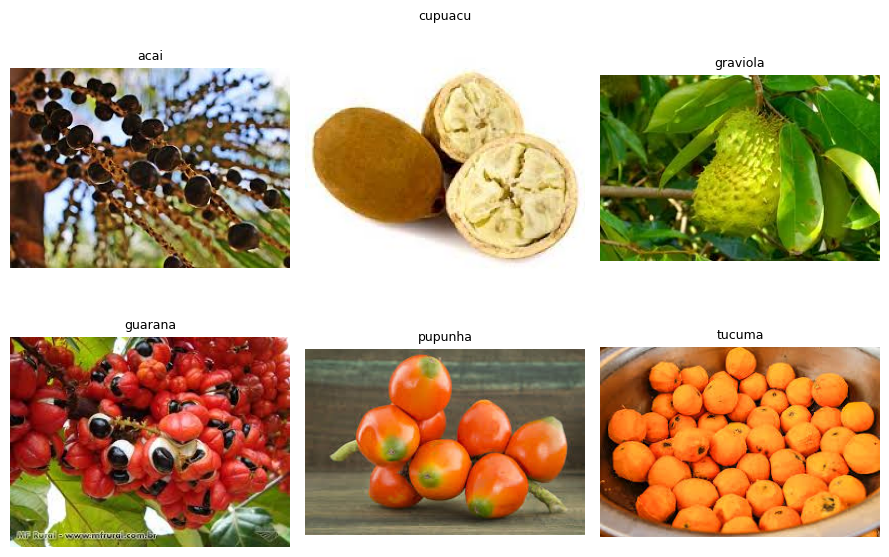

In [31]:
# Task 1a: Visualise one image per class
sample_images, sample_labels = [], []
for cls in class_dirs:
    cls_path = os.path.join(train_dir, cls)
    imgs = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    if imgs:
        sample_images.append(os.path.join(cls_path, random.choice(imgs)))
        sample_labels.append(cls)

n = len(sample_images)
cols = (n + 1) // 2
fig, axes = plt.subplots(2, cols, figsize=(cols * 3, 6))
axes = axes.flatten()
for i, (p, l) in enumerate(zip(sample_images, sample_labels)):
    axes[i].imshow(Image.open(p))
    axes[i].set_title(l, fontsize=9)
    axes[i].axis('off')
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

In [32]:
# Task 1b: Check for corrupted images
corrupted = []
for cls in class_dirs:
    cls_path = os.path.join(train_dir, cls)
    for fname in os.listdir(cls_path):
        fpath = os.path.join(cls_path, fname)
        try:
            img = Image.open(fpath)
            img.verify()
        except (IOError, SyntaxError):
            print(f'Removed corrupted image: {fpath}')
            os.remove(fpath)
            corrupted.append(fpath)

if not corrupted:
    print('No corrupted images found.')
else:
    print(f'Total removed: {len(corrupted)}')

No corrupted images found.


In [33]:
# Task 2: Load & preprocess data
IMG_HEIGHT = 128
IMG_WIDTH  = 128
BATCH_SIZE = 16
VAL_SPLIT  = 0.2
SEED       = 123

rescale = tf.keras.layers.Rescaling(1.0 / 255)

train_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, labels='inferred', label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH), interpolation='nearest',
    batch_size=BATCH_SIZE, shuffle=True,
    validation_split=VAL_SPLIT, subset='training', seed=SEED
)

val_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, labels='inferred', label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH), interpolation='nearest',
    batch_size=BATCH_SIZE, shuffle=False,
    validation_split=VAL_SPLIT, subset='validation', seed=SEED
)

class_names = train_ds_raw.class_names
num_classes = len(class_names)

#apply rescaling
train_ds = train_ds_raw.map(lambda x, y: (rescale(x), y))
val_ds   = val_ds_raw.map(lambda x, y: (rescale(x), y))

print('Classes:', class_names)
print('Num classes:', num_classes)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Num classes: 6


In [45]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.05),
])

In [46]:
# Task 3: Build CNN
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 3)),

    data_augmentation,

    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,408,902 (32.08 MB)

 Trainable params: 8,408,902 (32.08 MB)

 Non-trainable params: 0 (0.00 B)

In [47]:
# Task 4: Compile & Train
model.compile(
    optimizer = 'adam',
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True, verbose=1
)
checkpoint = keras.callbacks.ModelCheckpoint(
    'best_model.h5', monitor='val_accuracy', save_best_only=True, verbose=1
)

history = model.fit(
    train_ds,
    epochs=250,
    validation_data=val_ds,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.2788 - loss: 8.3315
Epoch 1: val_accuracy improved from None to 0.83333, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 249ms/step - accuracy: 0.2222 - loss: 9.6700 - val_accuracy: 0.8333 - val_loss: 0.9670
Epoch 2/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.2188 - loss: 2.7456
Epoch 2: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 178ms/step - accuracy: 0.2500 - loss: 2.3235 - val_accuracy: 0.0000e+00 - val_loss: 1.8888
Epoch 3/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.2656 - loss: 1.7548
Epoch 3: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.2222 - loss: 1.7469 - val_accuracy: 0.1111 - val_loss: 1.8728
Epoch 4/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.3438 - loss: 1.6796
Epoch 4: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.3194 - loss: 1.6500 - val_accuracy: 0.0556 - val_loss: 1.8029
Epoch 5/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.3490 - loss: 1.6274


Epoch 36: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 205ms/step - accuracy: 0.9306 - loss: 0.2555 - val_accuracy: 0.8889 - val_loss: 0.2059
Epoch 37/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9284 - loss: 0.2858
Epoch 37: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - accuracy: 0.9167 - loss: 0.2823 - val_accuracy: 0.8333 - val_loss: 0.2859
Epoch 38/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9531 - loss: 0.2008
Epoch 38: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - accuracy: 0.9306 - loss: 0.2296 - val_accuracy: 0.7222 - val_loss: 0.8122
Epoch 39/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9517 - loss: 0.2439
Epoch 39: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9306 - loss: 0.3030 - val_accuracy: 0.7778 - val_loss: 0.7373
Epoch 40/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9427 - loss: 0.


Epoch 56: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - accuracy: 0.9306 - loss: 0.1806 - val_accuracy: 0.9444 - val_loss: 0.2231
Epoch 57/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.9076 - loss: 0.2122
Epoch 57: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 156ms/step - accuracy: 0.9444 - loss: 0.2014 - val_accuracy: 0.8889 - val_loss: 0.3750
Epoch 58/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.9010 - loss: 0.2521
Epoch 58: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9444 - loss: 0.1934 - val_accuracy: 0.9444 - val_loss: 0.2140
Epoch 59/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8789 - loss: 0.2415
Epoch 59: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.8889 - loss: 0.2687 - val_accuracy: 0.8333 - val_loss: 0.3288
Epoch 59: early stopping
Restoring model weights from the end of the best epoch:

In [49]:
# Task 5: Evaluate on the test data
test_dir = "/content/drive/MyDrive/AI ML/FruitinAmazon/test"

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = test_ds.map(lambda x, y: (rescale(x), y))

test_loss, test_acc = model.evaluate(test_ds)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

Found 30 files belonging to 6 classes.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.8000 - loss: 0.4541
Test Accuracy: 0.800000011920929
Test Loss: 0.4541028141975403


In [50]:
# Task 6: Save & reload model
model.save("final_model.h5")

from tensorflow.keras.models import load_model

loaded_model = load_model("final_model.h5")

loss, acc = loaded_model.evaluate(test_ds)
print("Loaded Model Accuracy:", acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.8000 - loss: 0.4541 
Loaded Model Accuracy: 0.800000011920929


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
              precision    recall  f1-score   support

        acai       0.62      1.00      0.77         5
     cupuacu       0.80      0.80      0.80         5
    graviola       0.80      0.80      0.80         5
     guarana       0.83      1.00      0.91         5
     pupunha       1.00      0.80      0.89         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.80        30
   macro avg       0.84      0.80      0.79        30
weighted avg       0.84      0.80      0.79        30



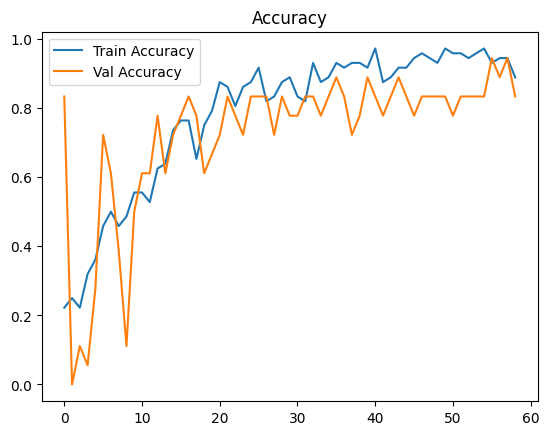

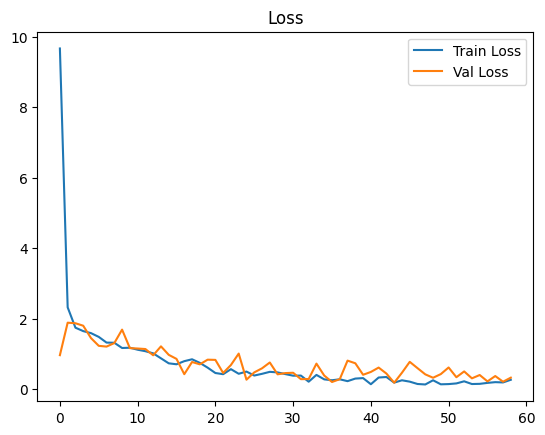

In [51]:
# Task 7: Predictions & Classification Report
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_pred.extend(preds)
    y_true.extend(labels.numpy())

print(classification_report(y_true, y_pred, target_names=class_names))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")
plt.show()

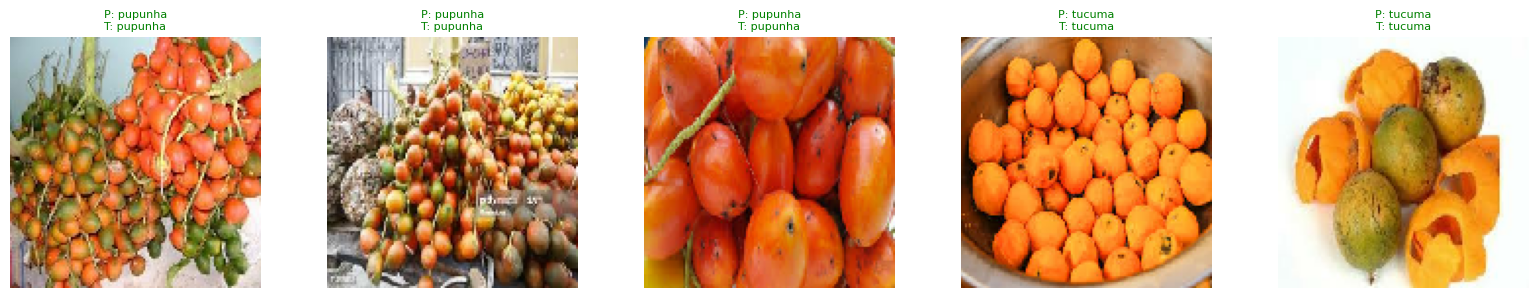

In [52]:
# Visualise 5 sample predictions
imgs_batch, lbls_batch = next(iter(val_ds))
preds5 = np.argmax(loaded_model.predict(imgs_batch[:5], verbose=0), axis=1)
true5  = lbls_batch[:5].numpy()

fig, axes = plt.subplots(1, 5, figsize=(16, 3))
for i in range(5):
    axes[i].imshow(imgs_batch[i].numpy())
    axes[i].set_title(
        f'P: {class_names[preds5[i]]}\nT: {class_names[true5[i]]}',
        color='green' if preds5[i]==true5[i] else 'red', fontsize=8
    )
    axes[i].axis('off')
plt.tight_layout()
plt.show()